In [2]:
import os
import timeit

import numpy as np
import pandas as pd
import plotnine as p9
from IPython import get_ipython

import pyvinecopulib as pv

ipython = get_ipython()

# Display plots inline in Jupyter Notebook
ipython.run_line_magic("matplotlib", "inline")

# Minimal reporting for exception handlers
ipython.run_line_magic("xmode", "minimal")

# Automatically reload modules when they have changed
ipython.run_line_magic("load_ext", "autoreload")
ipython.run_line_magic("autoreload", "2")

# Display all output from a cell (not just the last line)
ipython.run_line_magic(
  "config", "InteractiveShell.ast_node_interactivity='all'"
)

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", None)
pd.set_option("display.precision", 3)

# Numpy settings
np.printoptions(
  precision=4,
  suppress=True,
  formatter={"float": "{:0.4f}".format},
  linewidth=80,
)

Exception reporting mode: Minimal


In [48]:
from sklearn.model_selection import train_test_split
from vinesforest.vines_forest import VinesForest

# Read data
n_vines = 100
seed = 12
num_threads = min(32, os.cpu_count() + 4)  # See default for concurrent.futures
data = pd.read_csv("data/uranium.csv")
if any(data < 0) or any(data > 1):
  data[data.columns] = pv.to_pseudo_obs(data.values)
controls = pv.FitControlsVinecop(family_set=[pv.tll], num_threads=num_threads)

data_train, data_test = train_test_split(
  data,
  test_size=0.5,
  random_state=seed,
)

# Fit with Dissmann and forest
start = timeit.default_timer()
fitted_dissmann = pv.Vinecop.from_data(
  data_train.values,
  controls=controls,
)
loglik_dissmann_train = fitted_dissmann.loglik(data_train.values)
loglik_dissmann_test = fitted_dissmann.loglik(data_test.values)
time_dissmann = timeit.default_timer() - start

start = timeit.default_timer()
fitted_forest = VinesForest(
  n_vines=n_vines,
  controls=controls,
)
fitted_forest.fit(data_train.values)
loglik_forest_train = fitted_forest.loglik(data_train.values)
loglik_forest_test = fitted_forest.loglik(data_test.values)
time_forest = timeit.default_timer() - start

indicators_train = loglik_forest_train > loglik_dissmann_train
indicators_test = loglik_forest_test > loglik_dissmann_test

# Dissman vs max forest in train vs test
logliks = [
  ["Dissmann", "Train", loglik_dissmann_train],
  ["Dissmann", "Test", loglik_dissmann_test],
  ["Forest", "Train", max(loglik_forest_train)],
  ["Forest", "Test", max(loglik_forest_test)],
]
df_logliks = pd.DataFrame(logliks, columns=["Method", "Set", "Loglik"])
print(df_logliks)

# Time
print(time_dissmann)
print(time_forest)

# Proportion of the forest that is better than the dissman
print(np.mean(indicators_train))
print(np.mean(indicators_test))

     Method    Set   Loglik
0  Dissmann  Train  740.524
1  Dissmann   Test  241.437
2    Forest  Train  759.223
3    Forest   Test  366.507
0.10800417199789081
8.872387527997489
0.48
0.83


In [49]:
from sklearn.metrics import classification_report, confusion_matrix

indicators_train = loglik_forest_train > loglik_dissmann_train
indicators_test = loglik_forest_test > loglik_dissmann_test

confusion_matrix(indicators_test, indicators_train)
print(classification_report(indicators_test, indicators_train))

array([[ 9,  8],
       [43, 40]])

              precision    recall  f1-score   support

       False       0.17      0.53      0.26        17
        True       0.83      0.48      0.61        83

    accuracy                           0.49       100
   macro avg       0.50      0.51      0.44       100
weighted avg       0.72      0.49      0.55       100



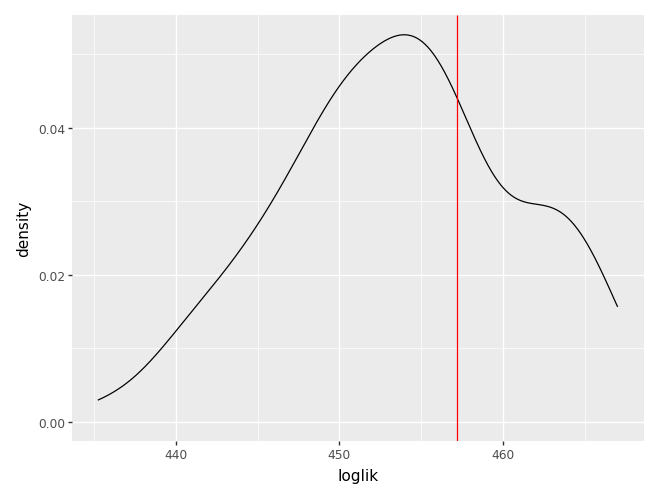

In [28]:
df = pd.DataFrame(loglik_forest_test, columns=["loglik"])

p = (
  p9.ggplot(df, p9.aes(x="loglik"))
  + p9.geom_density()
  + p9.geom_vline(xintercept=loglik_dissmann_test, color="red")
)
p.show()

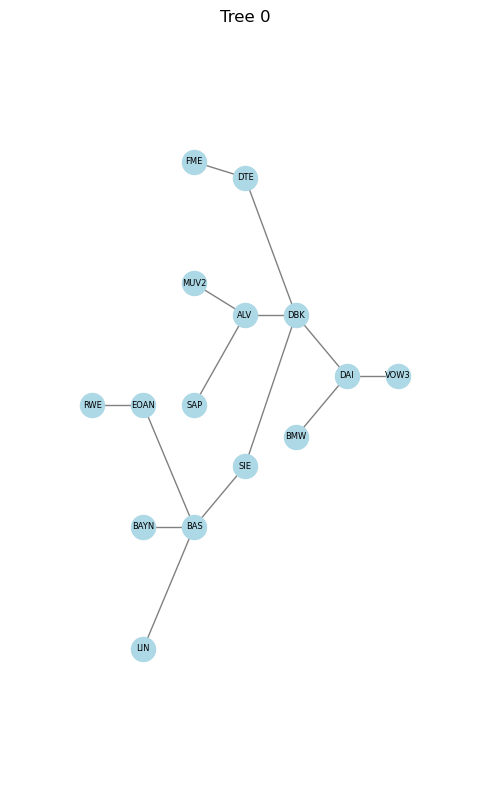

In [14]:
fitted_dissmann.plot(
  tree=[0],
  vars_names=list(data.columns.str.replace(".DE", "")),
  add_edge_labels=False,
)

In [ ]:
# best_vine_train = np.argmax(fitted_forest.loglik(data_train.values))

np.int64(70)

In [ ]:
# np.argmax(fitted_forest.loglik(data_test.values))

np.int64(35)

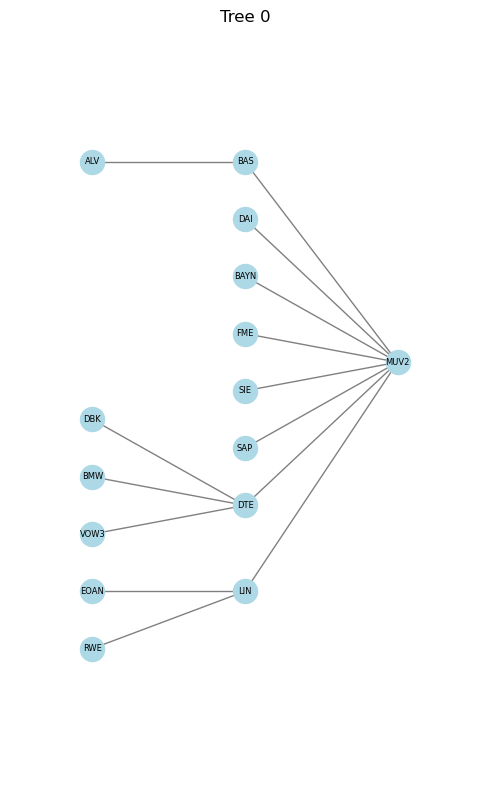

In [ ]:
# best_vine.plot(
#   tree=[0],
#   vars_names=list(data.columns.str.replace(".DE", "")),
#   add_edge_labels=False,
# )